# 01 · The Convolution Operation

> **Series:** How a Convolutional Neural Network Learns
> **Prerequisites:** basic linear algebra, NumPy familiarity
> **Renders to:** `results/01_convolution_sweep.gif`, `results/01_geometries.png`

A convolutional network learns by adjusting small grids of numbers called
**kernels**. Before we can watch them learn, we need to see precisely what a
kernel *does*. That is this notebook's only job.

By the end you will have rendered the animation the rest of the series builds
on: a kernel sweeping a digit, with the arithmetic shown as it happens.

## 1. Setup

Every notebook begins the same way: import `cnnviz`, apply the shared visual
style, fix a seed. The style module is what keeps figure 1 of notebook 01
speaking the same visual language as figure 9 of notebook 07.

All output goes to one flat folder, `results/`, via `results.output_path`.

Two rendering choices are set here and apply to everything below:

- **`theme="dark"`** — a selected dark theme, not an inverted light one. The
  sequential ramp reverses so that near-zero recedes into the surface, the
  diverging ramp takes a dark neutral midpoint and brightens toward both
  poles, and digits render bright-on-dark, which is how MNIST actually
  stores them.
- **`set_language("pt-BR")`** — localises every label baked into a figure,
  including the decimal separator. The notebook prose stays in English.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from cnnviz import style, panels, animate, results, text
from cnnviz.data import load_mnist
from cnnviz.layers import Conv2D

# The prose is English; the *rendered* output is Brazilian Portuguese on a
# dark surface. Both are switches, not rewrites — see cnnviz.text and
# cnnviz.style.
style.use_project_style(theme="dark")
text.set_language("pt-BR")

RNG = np.random.default_rng(0)
NOTEBOOK = 1

## 2. The input

We load MNIST **unnormalised**. This matters for a visual project: the
standardised version of a digit has negative pixel values and renders with a
muddy grey background. We train on normalised data later; we always *display*
the raw $[0, 1]$ version.

A full $28 \times 28$ digit is too large to annotate cell by cell, so we take
a $14 \times 14$ crop through the middle of a `7`, where the interesting
strokes are.

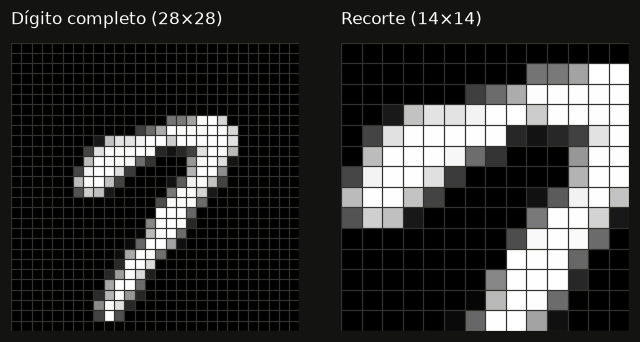

In [2]:
images, labels = load_mnist(train=True, normalize=False)

digit = images[np.flatnonzero(labels == 7)[0], 0]   # (28, 28)
patch_img = digit[6:20, 6:20]                        # (14, 14)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
panels.draw_matrix(axes[0], digit, mode="pixels",
                   title=f"{text.t('full_digit')} (28×28)")
panels.draw_matrix(axes[1], patch_img, mode="pixels",
                   title=f"{text.t('crop')} (14×14)")
plt.show()

## 3. What a convolution computes

For a single input channel, a kernel $w$ of size $K \times K$, and a bias $b$,
the output at position $(i, j)$ is

$$
y_{i,j} \;=\; b \;+\; \sum_{u=0}^{K-1} \sum_{v=0}^{K-1} w_{u,v} \; x_{\,i+u,\; j+v}
$$

In words: **line the kernel up over a patch of the image, multiply
element-wise, and add everything up.** That single number becomes one cell of
the output. Slide the kernel one step and repeat.

Two details worth pinning down now, because both cause confusion later.

**This is cross-correlation, not convolution.** A true convolution flips the
kernel before multiplying, i.e. it uses $w_{K-1-u,\,K-1-v}$. Every deep
learning framework skips the flip and calls it convolution anyway. Since the
kernel is *learned*, the flip would simply be absorbed into the learned
values — the mathematics is unaffected and only the name is wrong.

**The output shrinks.** With no padding and a stride of 1, a $K \times K$
kernel cannot be centred on the outermost pixels, so an $H \times W$ input
yields

$$
H_{\text{out}} = \left\lfloor \frac{H + 2p - K}{s} \right\rfloor + 1
$$

for padding $p$ and stride $s$. Our $14 \times 14$ crop with $K=3$, $p=0$,
$s=1$ gives $12 \times 12$.

## 4. A kernel we design by hand

Before letting the network *learn* a kernel, it helps to see one whose
behaviour we already understand. The **Sobel** operator detects vertical
edges:

$$
w = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}
$$

Read it as a question the kernel asks of every patch: *"is the right side
brighter than the left side?"* Where the patch is flat, the negative and
positive halves cancel and the answer is zero. Where brightness rises
left-to-right the sum is positive; falling, negative. The middle row is
weighted double so the row being centred on matters most.

This is why the feature map must be drawn with a **diverging** colour ramp.
The output is signed, and the sign is the entire message.

In [3]:
sobel_x = np.array([[-1.0, 0.0, 1.0],
                    [-2.0, 0.0, 2.0],
                    [-1.0, 0.0, 1.0]], dtype=np.float32)

conv = Conv2D(in_channels=1, out_channels=1, kernel_size=3, seed=0)
conv.W = sobel_x[None, None]              # (out, in, K, K)
conv.b = np.zeros(1, dtype=np.float32)

feature_map = conv.forward(patch_img[None, None])[0, 0]

print(f"input        {patch_img.shape}")
print(f"kernel       {sobel_x.shape}")
print(f"feature map  {feature_map.shape}   (predicted {conv.output_shape(14, 14)})")

input        (14, 14)
kernel       (3, 3)
feature map  (12, 12)   (predicted (12, 12))


### Verifying one cell by hand

The claim above is that each output cell is just a sum of nine products. It
costs three lines to check that, and checking it is the difference between
believing the formula and knowing it.

In [4]:
i, j = 5, 5
window = patch_img[i:i + 3, j:j + 3]
by_hand = float((window * sobel_x).sum())

print("patch under the kernel:")
print(np.round(window, 3))
print(f"\nby hand:      {by_hand:+.6f}")
print(f"from Conv2D:  {feature_map[i, j]:+.6f}")
assert np.isclose(by_hand, feature_map[i, j], atol=1e-5)

patch under the kernel:
[[0.961 0.424 0.208]
 [0.231 0.    0.   ]
 [0.    0.    0.   ]]

by hand:      -1.215686
from Conv2D:  -1.215686


## 5. The static result

Before animating, look at the endpoint. The kernel has turned a picture of a
digit into a map of *where vertical edges are*, and which way they point.

Note the colour choices, which recur throughout the series:

| Panel | Encoding | Why |
|---|---|---|
| Input | greyscale | raw imagery, not an encoding — colouring it would compete with the panels beside it |
| Kernel | diverging | weights are signed; $-1$ and $+1$ must look equally strong |
| Feature map | diverging | the output's sign carries the meaning |

The diverging ramp is always centred on zero, so a neutral cell genuinely
means "no response" rather than "the lowest value present".

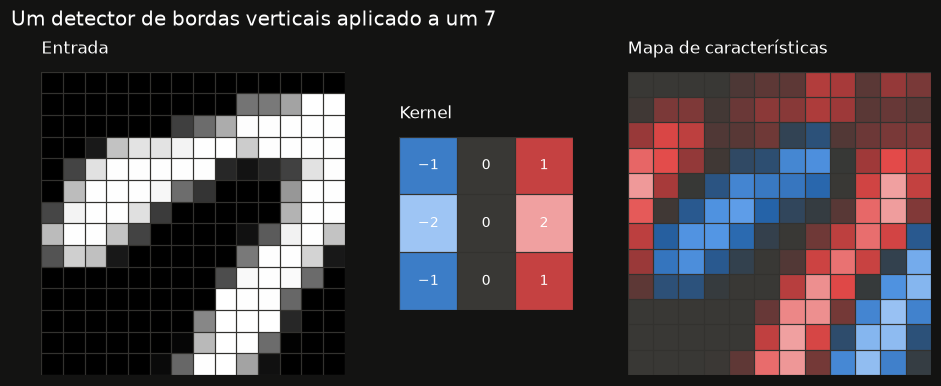

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.4), width_ratios=[1.25, 0.55, 1.25])

panels.draw_matrix(axes[0], patch_img, mode="pixels", title=text.t("input"))
panels.draw_kernel(axes[1], sobel_x, title=text.t("kernel").capitalize())
panels.draw_matrix(axes[2], feature_map, mode="signed", title=text.t("feature_map"))

fig.suptitle(text.t("static_title"), x=0.02, ha="left")
plt.show()

The bright and dark bands sit exactly on the digit's vertical strokes. The
horizontal bar of the `7` is nearly invisible — this kernel is blind to
horizontal edges, because a horizontal edge produces equal brightness on the
left and right of the window and the sum cancels.

That blindness is the point. **One kernel detects one kind of thing.** A real
convolutional layer runs dozens in parallel, and the network's job during
training is to discover which ones are worth having.

## 6. The animation

Now the sweep — and rather than just moving a box around, we show the
arithmetic. Each frame lays out the full expression:

$$
\text{patch} \;\odot\; \text{kernel} \;=\; \text{products}
\qquad\longrightarrow\qquad \text{sum}
$$

so the viewer can follow a single number from nine multiplications to its
cell in the feature map.

Three deliberate choices in the rendering:

- **Uncomputed cells are masked, not zeroed.** They render in a flat neutral
  that is visibly distinct from the diverging ramp's midpoint — otherwise a
  cell that has not been computed looks identical to one whose response is
  genuinely zero.
- **The timing is not uniform.** The first few positions are held longer so
  the mechanic can be learned before it speeds up, and the strongest response
  in the whole map gets an extra beat.
- **Every panel uses a colour scale fixed over the whole sweep.** A panel that
  rescales to its own frame would render nine near-zero products as vividly as
  a strong edge, contradicting the sum printed beneath it.
- **The layout engine is switched off** during animation, so no panel drifts
  between frames.

Rendering takes roughly two minutes for 144 frames.

In [6]:
positions = [(i, j) for i in range(feature_map.shape[0])
                    for j in range(feature_map.shape[1])]

TOP, BOTTOM = 0.735, 0.215

# Fixed colour scales, computed once over the WHOLE sweep.
#
# Without these, each panel would rescale itself to whatever it happens to
# hold in the current frame — so a patch of nine near-zero products would
# render just as saturated as one containing a strong edge, and the animation
# would visually contradict the "sum" printed underneath it.
all_products = np.stack([
    patch_img[r:r + 3, c:c + 3] * sobel_x for r, c in positions
])
NORM_PATCH    = style.magnitude_norm(patch_img, robust=False)
NORM_KERNEL   = style.signed_norm(sobel_x, robust=False)
NORM_PRODUCTS = style.signed_norm(all_products, robust=False)
NORM_FMAP     = style.signed_norm(feature_map, robust=False)


def draw_sweep(fig, k):
    row, col = positions[k]
    window = patch_img[row:row + 3, col:col + 3]
    products = window * sobel_x
    total = float(products.sum())

    gs = GridSpec(
        1, 5, figure=fig,
        width_ratios=[1.30, 0.52, 0.52, 0.52, 1.30],
        left=0.012, right=0.974, top=TOP, bottom=BOTTOM, wspace=0.50,
    )
    ax_in, ax_pa, ax_ke, ax_pr, ax_out = (fig.add_subplot(gs[0, c]) for c in range(5))
    band_mid = (TOP + BOTTOM) / 2

    panels.draw_matrix(ax_in, patch_img, mode="pixels", norm=NORM_PATCH,
                       title=f"{text.t('input')}   14×14", title_fontsize=10.5)
    panels.highlight_window(ax_in, row, col, size=3)

    panels.draw_matrix(ax_pa, window, mode="pixels", norm=NORM_PATCH,
                       annotate=True, fontsize=7.5, title=text.t("patch"),
                       title_fontsize=10.5)
    panels.draw_matrix(ax_ke, sobel_x, mode="signed", norm=NORM_KERNEL,
                       annotate=True, fontsize=8, title=text.t("kernel"),
                       title_fontsize=10.5)
    panels.draw_matrix(ax_pr, products, mode="signed", norm=NORM_PRODUCTS,
                       annotate=True, fontsize=7.5, title=text.t("products"),
                       title_fontsize=10.5)

    # Operator glyphs are placed from the axes' realised positions rather than
    # hardcoded, so they stay centred if the layout is ever retuned.
    for left_ax, right_ax, symbol in ((ax_pa, ax_ke, "⊙"), (ax_ke, ax_pr, "=")):
        x = (left_ax.get_position().x1 + right_ax.get_position().x0) / 2
        fig.text(x, band_mid, symbol, ha="center", va="center",
                 fontsize=16, color=style.INK_MUTED)

    revealed = np.ma.masked_all(feature_map.shape, dtype=feature_map.dtype)
    revealed.flat[:k + 1] = feature_map.flat[:k + 1]
    panels.draw_matrix(ax_out, revealed, mode="signed", norm=NORM_FMAP,
                       title=f"{text.t('feature_map')}   12×12",
                       title_fontsize=10.5)
    panels.highlight_window(ax_out, row, col, size=1)

    expression = (ax_pa.get_position().x0 + ax_pr.get_position().x1) / 2
    fig.text(expression, 0.170,
             f"{text.t('sum')}  =  {text.num(total, 2)}",
             ha="center", va="top", fontsize=12.5, color=style.INK_PRIMARY)

    panels.frame_header(fig, text.t("conv_title"), text.t("conv_subtitle"))

    reading = text.t("strong_edge") if abs(total) > 1.2 else text.t("weak_edge")
    position = text.t("position_of", k=k + 1, n=len(positions))
    panels.caption(fig, f"{position}   ·   {reading}")
    panels.progress_bar(fig, (k + 1) / len(positions))


# Hold the opening positions so the mechanic registers before it accelerates,
# and give the strongest response in the map an extra beat.
holds = {0: 1.0, 1: 0.7, 2: 0.5, 3: 0.35, 4: 0.25}
holds[int(np.argmax(np.abs(feature_map)))] = 1.1

animate.animate(
    draw_sweep,
    n_frames=len(positions),
    path=results.output_path("convolution_sweep.gif", notebook=NOTEBOOK),
    figsize=(11.5, 4.3),
    durations=animate.hold_at(len(positions), fps=11, holds=holds),
)

01_convolution_sweep:   0%|          | 0/144 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/01_convolution_sweep.gif')

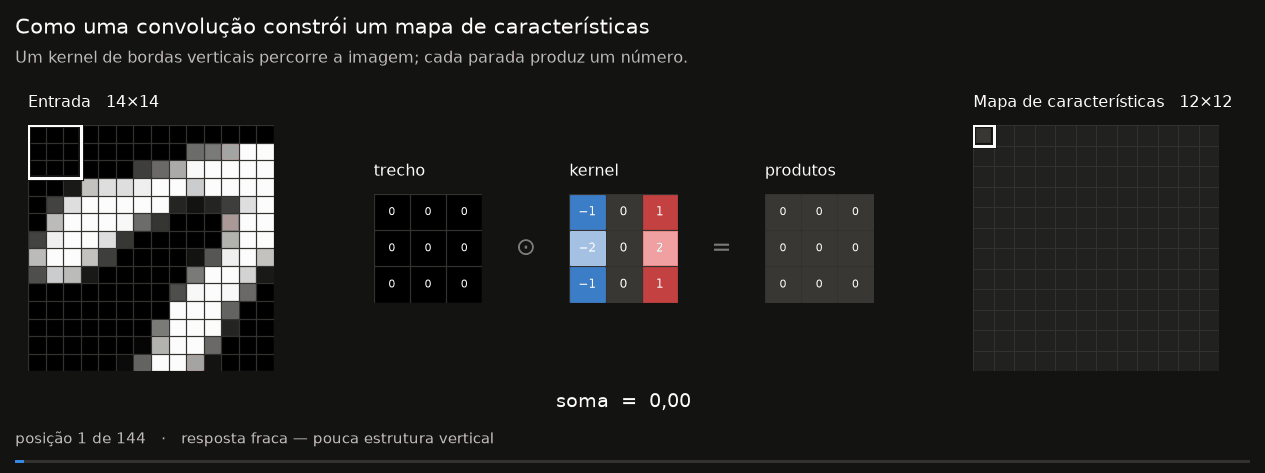

In [7]:
from IPython.display import Image, display

display(Image(filename=str(results.output_path("01_convolution_sweep.gif"))))

## 7. Stride and padding, seen directly

Two hyperparameters change the geometry of the sweep. Rather than describe
them, render them: the same kernel, the same input, three configurations.

- **stride** $s$ — how far the window jumps each step. Larger stride means
  fewer positions and a smaller output; it is a form of downsampling.
- **padding** $p$ — a border of zeros added before sweeping. With
  $p = \lfloor K/2 \rfloor$ the output keeps the input's size, which is why
  `padding=1` accompanies almost every $3 \times 3$ convolution in practice.

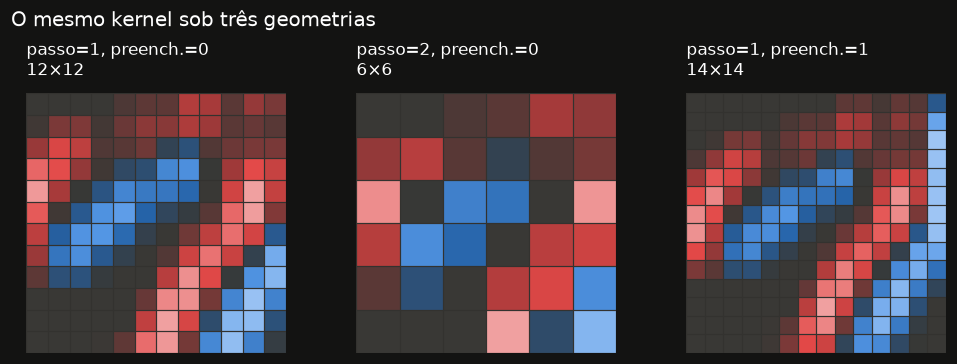

In [8]:
configs = [(1, 0), (2, 0), (1, 1)]

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, (stride, padding) in zip(axes, configs):
    c = Conv2D(1, 1, kernel_size=3, stride=stride, padding=padding, seed=0)
    c.W, c.b = sobel_x[None, None], np.zeros(1, dtype=np.float32)
    out = c.forward(patch_img[None, None])[0, 0]
    panels.draw_matrix(
        ax, out, mode="signed",
        title=(f"{text.t('stride')}={stride}, {text.t('padding')}={padding}\n"
               f"{out.shape[0]}×{out.shape[1]}"),
    )

fig.suptitle(text.t("geometries_title"), x=0.02, ha="left")
fig.savefig(results.output_path("geometries.png", notebook=NOTEBOOK), dpi=140)
plt.show()

Notice that stride 2 does not merely shrink the map — it *samples* it. Fine
detail present at stride 1 is simply never computed. That is the trade the
network makes for cheaper computation and a larger receptive field.

## 10. A cut for a phone feed

The wide layout above is built for a notebook. Dropped into a social feed it
fails: the type ends up a handful of pixels tall and the viewer scrolls past
in under a second. A feed version is a **different layout on a different
canvas**, not the same figure scaled down.

What changes, and why:

- **4:5 portrait, 1080×1350.** The tallest a feed post may be, so it holds
  the most screen as the viewer scrolls. `cnnviz.formats` also carries `1:1`
  and `9:16` presets.
- **Panels stack.** Two large panels — input and feature map — sit above the
  arithmetic, because five panels in a row are unreadable at this width.
- **Type roughly doubles**, via the preset's `scale`.
- **Shorter title.** `conv_title_short`, not the long title at a smaller size:
  a title that has to be squinted at is worse than a shorter one that reads
  at a glance.
- **A bigger colour palette.** At 64 colours the shared palette started
  approximating greyscale pixels with nearby blues and reds — a visible
  colour cast on the digit. Mixing a grey ramp with a diverging one in one
  frame needs the headroom.
- **Faster, ~12 s.** Feeds autoplay muted and loop; the whole thing has to be
  worth watching twice.

### It also writes an MP4

**Instagram and TikTok reject GIF uploads**, and X/Twitter and WhatsApp
transcode any GIF to video anyway. `mp4=True` writes an H.264 file beside the
GIF — smaller, and actually postable. Keep the GIF for GitHub and messaging.

In [9]:
from cnnviz import formats

C = formats.FEED_PORTRAIT

def draw_feed(fig, k):
    row, col = positions[k]
    window = patch_img[row:row + 3, col:col + 3]
    products = window * sobel_x
    total = float(products.sum())

    # Two big panels on top, the equation beneath them.
    gs_top = GridSpec(1, 2, figure=fig, left=0.06, right=0.94,
                      top=0.855, bottom=0.505, wspace=0.12)
    ax_in  = fig.add_subplot(gs_top[0, 0])
    ax_out = fig.add_subplot(gs_top[0, 1])

    gs_eq = GridSpec(1, 3, figure=fig, left=0.10, right=0.90,
                     top=0.415, bottom=0.245, wspace=0.55)
    ax_pa = fig.add_subplot(gs_eq[0, 0])
    ax_ke = fig.add_subplot(gs_eq[0, 1])
    ax_pr = fig.add_subplot(gs_eq[0, 2])

    panels.draw_matrix(ax_in, patch_img, mode="pixels", norm=NORM_PATCH,
                       title=text.t("input"), title_fontsize=C.pt(11))
    panels.highlight_window(ax_in, row, col, 3, linewidth=3.0)

    revealed = np.ma.masked_all(feature_map.shape, dtype=feature_map.dtype)
    revealed.flat[:k+1] = feature_map.flat[:k+1]
    panels.draw_matrix(ax_out, revealed, mode="signed", norm=NORM_FMAP,
                       title=text.t("feature_map"), title_fontsize=C.pt(11))
    panels.highlight_window(ax_out, row, col, 1, linewidth=3.0)

    panels.draw_matrix(ax_pa, window, mode="pixels", norm=NORM_PATCH, annotate=True,
                       fontsize=C.pt(7.0), title=text.t("patch"), title_fontsize=C.pt(10))
    panels.draw_matrix(ax_ke, sobel_x, mode="signed", norm=NORM_KERNEL, annotate=True,
                       fontsize=C.pt(7.0), title=text.t("kernel"), title_fontsize=C.pt(10))
    panels.draw_matrix(ax_pr, products, mode="signed", norm=NORM_PRODUCTS, annotate=True,
                       fontsize=C.pt(7.0), title=text.t("products"), title_fontsize=C.pt(10))

    band = (0.415 + 0.245) / 2
    for left_ax, right_ax, sym in ((ax_pa, ax_ke, "⊙"), (ax_ke, ax_pr, "=")):
        x = (left_ax.get_position().x1 + right_ax.get_position().x0) / 2
        fig.text(x, band, sym, ha="center", va="center",
                 fontsize=C.pt(15), color=style.INK_MUTED)

    fig.text(0.5, 0.163, f"{text.t('sum')}  =  {text.num(total, 2)}",
             ha="center", va="bottom", fontsize=C.pt(15), color=style.INK_PRIMARY)

    fig.text(0.06, 0.972, text.t("conv_title_short"), ha="left", va="top",
             fontsize=C.pt(13.5), color=style.INK_PRIMARY)
    fig.text(0.06, 0.928, text.t("conv_subtitle_short"), ha="left", va="top",
             fontsize=C.pt(8.5), color=style.INK_SECONDARY)

    reading = text.t("strong_edge") if abs(total) > 1.2 else text.t("weak_edge")
    fig.text(0.5, 0.108, reading, ha="center", va="bottom",
             fontsize=C.pt(8.5), color=style.INK_SECONDARY)
    panels.caption(fig, text.t("position_of", k=k+1, n=len(positions)),
                   x=0.5, y=0.072, fontsize=C.pt(7.5), ha="center")
    panels.progress_bar(fig, (k+1)/len(positions), y=0.040,
                        x=0.06, width=0.88, height=0.005)


feed_holds = {0: 1.2, 1: 0.7, 2: 0.45,
              int(np.argmax(np.abs(feature_map))): 1.0}

animate.animate(
    draw_feed,
    n_frames=len(positions),
    path=results.output_path("convolution_sweep_feed.gif", notebook=NOTEBOOK),
    figsize=C.figsize,
    colors=160,
    mp4=True,
    durations=animate.hold_at(len(positions), fps=15, holds=feed_holds,
                              first=0.8, last=1.5),
)

01_convolution_sweep_feed:   0%|          | 0/144 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/01_convolution_sweep_feed.gif')

## 8. Refresh the results index

`results/` carries its own generated gallery so the folder is self-describing
wherever it is opened. Regenerate it after rendering.

In [10]:
results.write_index()

for item in results.list_results():
    print(f"{item.name:34s} {item.stat().st_size / 1e6:6.2f} MB")

01_convolution_sweep.gif             0.85 MB
01_convolution_sweep_feed.gif        1.85 MB
01_convolution_sweep_feed.mp4        1.15 MB
01_geometries.png                    0.03 MB


## 9. What we have, and what is missing

We can now state precisely what a convolutional layer does in the forward
direction, and watch it happen number by number.

But `sobel_x` was **handed** to the network. Nobody told a real CNN to look
for vertical edges; it works that out from data. The gap between those two
situations — a kernel we chose and a kernel that was learned — is the subject
of the rest of the series.

**Next:** `02_stacking_layers.ipynb` — what happens when the output of one
convolution becomes the input of the next, and why depth buys hierarchy.